# Training Prediksi Nilai Pasar Musim Berikutnya

Notebook ini memperlihatkan proses training, pemilihan model, test, feature importance, forecast 2025, dan visualisasi secara bertahap. Jalankan 02_preprocessing.ipynb terlebih dahulu.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import xgboost
from IPython.display import display
from imblearn.over_sampling import RandomOverSampler
from joblib import dump
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

PROJECT_ROOT = Path.cwd()
MODEL_DATA_FILE = PROJECT_ROOT / "data" / "model" / "players_model.csv"
FEATURE_LIST_FILE = PROJECT_ROOT / "data" / "model" / "feature_list.json"
FORECAST_DATA_FILE = PROJECT_ROOT / "data" / "processed" / "forecast_dataset.csv"

OUTPUT_DIR = PROJECT_ROOT / "data" / "output"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
for directory in [OUTPUT_DIR, MODELS_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TARGET = "next_season_market_value_mio"
GROWTH_TARGET = "next_season_log_growth"
RANDOM_STATE = 42

print("Project root:", PROJECT_ROOT)

Project root: c:\KULIAH\SEMESTER 6\BIG DATA\UAS\Tugas_UAS_Big-Data


## 1. Membaca Dataset dan Daftar Fitur

In [2]:
for path in [MODEL_DATA_FILE, FEATURE_LIST_FILE, FORECAST_DATA_FILE]:
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(
            f"File tidak tersedia: {path}. Jalankan 02_preprocessing.ipynb terlebih dahulu."
        )

model_data = pd.read_csv(MODEL_DATA_FILE)
forecast_data = pd.read_csv(FORECAST_DATA_FILE)
with open(FEATURE_LIST_FILE, "r", encoding="utf-8") as file:
    feature_list = json.load(file)

missing_features = [feature for feature in feature_list if feature not in model_data.columns]
if missing_features:
    raise ValueError(f"Fitur tidak tersedia: {missing_features}")

model_data[GROWTH_TARGET] = np.log(model_data[TARGET] / model_data["current_market_value_mio"])
if not np.isfinite(model_data[GROWTH_TARGET]).all():
    raise ValueError("Target pertumbuhan mengandung nilai tidak valid.")

forbidden_features = [feature for feature in feature_list if feature.startswith("next_season_")]
if forbidden_features:
    raise ValueError(f"Target leakage ditemukan: {forbidden_features}")

print(f"Rows model: {len(model_data):,}")
print(f"Jumlah fitur: {len(feature_list)}")
display(model_data.head())

Rows model: 8,090
Jumlah fitur: 29


,player_id,player_name,club,season,target_season,age,height_m,preferred_foot,pos_category,league,...,shots_on_target,starts_rate,goals_per_90,assists_per_90,goal_assist_per_90,shots_per_90,has_performance_stats,next_season_market_value_mio,next_season_market_value_category,next_season_log_growth
0,3333,James Milner,Liverpool FC,2017,2018,32.0,1.75,right,Midfield,Premier League,...,5.0,0.500000,0.000000,0.152113,0.152113,1.064789,1.0,15.0,Menengah,0.000000
1,3333,James Milner,Liverpool FC,2018,2019,33.0,1.75,right,Midfield,Premier League,...,8.0,0.612903,0.251537,0.201230,0.452767,1.207378,1.0,6.5,Rendah,-0.836248
2,3333,James Milner,Liverpool FC,2019,2020,34.0,1.75,right,Midfield,Premier League,...,4.0,0.409091,0.192102,0.192102,0.384205,1.152615,1.0,3.0,Rendah,-0.773190
3,4360,Arjen Robben,Bayern Munich,2017,2018,34.0,1.80,left,Attack,Bundesliga,...,21.0,0.904762,0.298607,0.298607,0.597213,3.045786,1.0,4.0,Rendah,-0.559616
4,6288,Mario Gómez,VfB Stuttgart,2017,2018,32.0,1.89,right,Attack,Bundesliga,...,15.0,1.000000,0.519856,0.000000,0.519856,2.144404,1.0,2.0,Rendah,-1.098612


## 2. Time-Based Split

Split dibuat berdasarkan target season, bukan feature season.

In [3]:
train_data = model_data[model_data["target_season"] <= 2022].copy()
validation_data = model_data[model_data["target_season"] == 2023].copy()
test_data = model_data[model_data["target_season"] == 2024].copy()

if min(len(train_data), len(validation_data), len(test_data)) == 0:
    raise ValueError("Train, validation, atau test kosong.")

X_train = train_data[feature_list]
y_train = train_data[GROWTH_TARGET]
X_validation = validation_data[feature_list]
y_validation = validation_data[GROWTH_TARGET]
X_test = test_data[feature_list]
y_test = test_data[GROWTH_TARGET]

categorical_features = [
    column for column in feature_list
    if model_data[column].dtype == "object"
]
numeric_features = [
    column for column in feature_list
    if column not in categorical_features
]

split_summary = pd.DataFrame([
    {"split": "Train", "target_season": "2018-2022", "rows": len(train_data)},
    {"split": "Validation", "target_season": "2023", "rows": len(validation_data)},
    {"split": "Test", "target_season": "2024", "rows": len(test_data)},
])
display(split_summary)
print("Categorical features:", categorical_features)
print("Numeric features:", len(numeric_features))

TRAIN_BEFORE_FILE = PROJECT_ROOT / "data" / "model" / "train_before_oversampling.csv"
TRAIN_AFTER_FILE = PROJECT_ROOT / "data" / "model" / "train_after_oversampling.csv"
HIGH_BEFORE_FILE = PROJECT_ROOT / "data" / "model" / "train_high_before_oversampling.csv"
HIGH_AFTER_FILE = PROJECT_ROOT / "data" / "model" / "train_high_after_oversampling.csv"
OVERSAMPLING_SUMMARY_FILE = OUTPUT_DIR / "oversampling_summary.csv"

def light_oversampling_strategy(labels):
    counts = pd.Series(labels).value_counts()
    target_count = int(counts.max() * 0.85)
    return {label: target_count for label, count in counts.items() if count < target_count}

train_before_export = train_data.copy().reset_index(drop=True)
train_before_export["_source_row_id"] = np.arange(len(train_before_export))
train_before_export["_oversampling_status"] = "Original"
train_before_export["_is_oversampled_duplicate"] = False
train_categories = train_before_export["next_season_market_value_category"]
sampler = RandomOverSampler(sampling_strategy=light_oversampling_strategy(train_categories), random_state=RANDOM_STATE)
train_after_oversampling, _ = sampler.fit_resample(train_before_export, train_categories)
train_after_oversampling = train_after_oversampling.reset_index(drop=True)
duplicate_mask = np.arange(len(train_after_oversampling)) >= len(train_before_export)
train_after_oversampling["_is_oversampled_duplicate"] = duplicate_mask
train_after_oversampling["_oversampling_status"] = np.where(duplicate_mask, "Tambahan oversampling", "Original")

before_counts = train_before_export["next_season_market_value_category"].value_counts()
after_counts = train_after_oversampling["next_season_market_value_category"].value_counts()
oversampling_summary = pd.DataFrame({
    "category": ["Rendah", "Menengah", "Tinggi"],
    "before_records": [int(before_counts.get(label, 0)) for label in ["Rendah", "Menengah", "Tinggi"]],
    "after_records": [int(after_counts.get(label, 0)) for label in ["Rendah", "Menengah", "Tinggi"]],
})
oversampling_summary["added_records"] = oversampling_summary["after_records"] - oversampling_summary["before_records"]
oversampling_summary["source_split"] = "train_target_2018_2022"

train_before_export.to_csv(TRAIN_BEFORE_FILE, index=False)
train_after_oversampling.to_csv(TRAIN_AFTER_FILE, index=False)
train_before_export[train_before_export["next_season_market_value_category"] == "Tinggi"].to_csv(HIGH_BEFORE_FILE, index=False)
train_after_oversampling[train_after_oversampling["next_season_market_value_category"] == "Tinggi"].to_csv(HIGH_AFTER_FILE, index=False)
oversampling_summary.to_csv(OVERSAMPLING_SUMMARY_FILE, index=False)

display(oversampling_summary)
print("Oversampling hanya diterapkan pada training. Validation dan test tidak berubah.")

,split,target_season,rows
0,Train,2018-2022,5701
1,Validation,2023,1190
2,Test,2024,1199


Categorical features: ['preferred_foot', 'pos_category', 'league', 'current_market_value_category']
Numeric features: 25


,category,before_records,after_records,added_records,source_split
0,Rendah,3171,3171,0,train_target_2018_2022
1,Menengah,1787,2695,908,train_target_2018_2022
2,Tinggi,743,2695,1952,train_target_2018_2022


Oversampling hanya diterapkan pada training. Validation dan test tidak berubah.


## 3. Fungsi Model dan Evaluasi

Target model adalah log rasio nilai musim berikutnya terhadap nilai saat ini. Prediksi nilai akhir dihitung dengan nilai saat ini dikali exp(prediksi log-growth), sehingga pemain tetap memiliki anchor pada valuasi terakhir.

In [4]:
def value_category(value):
    if value < 15:
        return "Rendah"
    if value <= 35:
        return "Menengah"
    return "Tinggi"


def evaluate_regression(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.maximum(np.asarray(y_pred, dtype=float), 0)
    absolute_error = np.abs(y_true - y_pred)
    actual_categories = np.array([value_category(value) for value in y_true])
    predicted_categories = np.array([value_category(value) for value in y_pred])
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
        "mape": np.mean(absolute_error / np.maximum(y_true, 1)),
        "within_5_mio": np.mean(absolute_error <= 5),
        "category_accuracy": np.mean(actual_categories == predicted_categories),
    }


def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_estimator(model_name):
    preprocessor = ColumnTransformer([
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", make_encoder(), categorical_features),
    ], remainder="drop")

    if model_name == "ridge_regression":
        regressor = Ridge(alpha=10.0)
    elif model_name == "xgboost_regressor":
        regressor = XGBRegressor(
            n_estimators=650,
            max_depth=4,
            learning_rate=0.035,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="reg:squarederror",
            eval_metric="mae",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    else:
        raise ValueError(f"Model tidak dikenal: {model_name}")

    pipeline = Pipeline([
        ("preprocess", preprocessor),
        ("model", regressor),
    ])
    return pipeline


print("Fungsi model siap.")

Fungsi model siap.


## 4. Baseline dan Training Kandidat Model

Baseline menganggap nilai pasar musim berikutnya sama dengan nilai pasar musim saat ini.

In [5]:
validation_rows = []

baseline_validation_prediction = validation_data["current_market_value_mio"].to_numpy()
validation_rows.append({
    "model": "baseline_nilai_saat_ini",
    "split": "validation",
    **evaluate_regression(validation_data[TARGET], baseline_validation_prediction),
})

trained_candidates = {}
training_scenarios = {
    "no_sampling": train_before_export,
    "random_oversampling_light": train_after_oversampling,
}
for model_name in ["ridge_regression", "xgboost_regressor"]:
    for scenario, scenario_data in training_scenarios.items():
        print(f"Training {model_name} | {scenario}...")
        estimator = make_estimator(model_name)
        estimator.fit(scenario_data[feature_list], scenario_data[GROWTH_TARGET])
        predicted_log_growth = estimator.predict(X_validation)
        prediction = X_validation["current_market_value_mio"].to_numpy() * np.exp(predicted_log_growth)
        trained_candidates[(model_name, scenario)] = estimator
        validation_rows.append({
            "model": model_name,
            "scenario": scenario,
            "split": "validation",
            **evaluate_regression(validation_data[TARGET], prediction),
        })

validation_metrics = (
    pd.DataFrame(validation_rows)
    .sort_values("mae")
    .reset_index(drop=True)
)
trainable_metrics = validation_metrics[
    validation_metrics["model"] != "baseline_nilai_saat_ini"
]
best_model_name = trainable_metrics.iloc[0]["model"]
best_scenario = trainable_metrics.iloc[0]["scenario"]

display(validation_metrics)
print("Model terbaik berdasarkan validation MAE:", best_model_name)
print("Skenario terbaik:", best_scenario)

Training ridge_regression | no_sampling...
Training ridge_regression | random_oversampling_light...
Training xgboost_regressor | no_sampling...
Training xgboost_regressor | random_oversampling_light...


,model,split,mae,rmse,r2,mape,within_5_mio,category_accuracy,scenario
0,xgboost_regressor,validation,5.443290,8.694147,0.841468,0.359899,0.663866,0.794118,no_sampling
1,xgboost_regressor,validation,5.500104,8.630980,0.843763,0.382228,0.645378,0.797479,random_oversampling_light
2,ridge_regression,validation,5.653158,9.214111,0.821938,0.355702,0.670588,0.790756,no_sampling
3,ridge_regression,validation,5.674854,9.082969,0.826971,0.386055,0.645378,0.789916,random_oversampling_light
4,baseline_nilai_saat_ini,validation,5.927983,9.052983,0.828111,0.479905,0.661345,0.773950,NaN


Model terbaik berdasarkan validation MAE: xgboost_regressor
Skenario terbaik: no_sampling


## 5. Evaluasi Final pada Test 2024

Model terpilih dilatih ulang memakai train dan validation, lalu dievaluasi satu kali pada test.

In [6]:
train_validation_data = pd.concat(
    [train_data, validation_data],
    ignore_index=True,
)

def apply_training_scenario(data, scenario):
    if scenario == "no_sampling":
        return data.reset_index(drop=True)
    labels = data["next_season_market_value_category"]
    local_sampler = RandomOverSampler(sampling_strategy=light_oversampling_strategy(labels), random_state=RANDOM_STATE)
    sampled, _ = local_sampler.fit_resample(data, labels)
    return sampled.reset_index(drop=True)

evaluation_training_data = apply_training_scenario(train_validation_data, best_scenario)

evaluation_model = make_estimator(best_model_name)
evaluation_model.fit(
    evaluation_training_data[feature_list],
    evaluation_training_data[GROWTH_TARGET],
)

test_log_growth_prediction = evaluation_model.predict(X_test)
test_prediction = X_test["current_market_value_mio"].to_numpy() * np.exp(test_log_growth_prediction)
baseline_test_prediction = test_data["current_market_value_mio"].to_numpy()

test_metrics = pd.DataFrame([
    {
        "model": "baseline_nilai_saat_ini",
        "split": "test",
        **evaluate_regression(test_data[TARGET], baseline_test_prediction),
    },
    {
        "model": best_model_name,
        "scenario": best_scenario,
        "split": "test",
        **evaluate_regression(test_data[TARGET], test_prediction),
    },
])
model_metrics = pd.concat(
    [validation_metrics, test_metrics],
    ignore_index=True,
)

test_predictions = test_data[[
    "player_id", "player_name", "club", "season", "target_season",
    "current_market_value_mio", TARGET,
]].copy()
test_predictions["predicted_market_value_mio"] = test_prediction
test_predictions["absolute_error_mio"] = np.abs(
    test_predictions[TARGET] - test_prediction
)
test_predictions["actual_category"] = test_predictions[TARGET].map(value_category)
test_predictions["predicted_category"] = (
    test_predictions["predicted_market_value_mio"].map(value_category)
)

display(test_metrics)
display(
    test_predictions.sort_values("absolute_error_mio").head(20)
)

,model,split,mae,rmse,r2,mape,within_5_mio,category_accuracy,scenario
0,baseline_nilai_saat_ini,test,6.994662,11.123851,0.757719,0.499272,0.607173,0.753962,NaN
1,xgboost_regressor,test,6.077335,9.959404,0.805788,0.376363,0.612177,0.782319,no_sampling


,player_id,player_name,club,season,target_season,current_market_value_mio,next_season_market_value_mio,predicted_market_value_mio,absolute_error_mio,actual_category,predicted_category
3089,193004,Waldemar Anton,VfB Stuttgart,2023,2024,20.0,18.0,17.994258,0.005742,Menengah,Menengah
3732,229804,Aritz Elustondo,Real Sociedad,2023,2024,5.0,3.0,2.993721,0.006279,Rendah,Rendah
1725,119296,Emre Can,Borussia Dortmund,2023,2024,10.0,7.0,7.011973,0.011973,Rendah,Rendah
2035,130164,Jordan Pickford,Everton FC,2023,2024,22.0,18.0,17.987186,0.012814,Menengah,Menengah
7916,711517,Kevin Paredes,VfL Wolfsburg,2023,2024,7.5,7.5,7.481339,0.018661,Rendah,Rendah
5427,338425,Álex Berenguer,Athletic Bilbao,2023,2024,12.0,9.0,9.019994,0.019994,Rendah,Rendah
5797,354814,M'Bala Nzola,ACF Fiorentina,2023,2024,7.0,6.0,6.020768,0.020768,Rendah,Rendah
3893,240692,Reinildo Mandava,Atlético de Madrid,2023,2024,9.0,5.0,4.979198,0.020802,Rendah,Rendah
4048,250779,Brendan Chardonnet,Stade Brestois 29,2023,2024,8.0,6.0,6.029143,0.029143,Rendah,Rendah
7009,480692,Luis Díaz,Liverpool FC,2023,2024,75.0,70.0,69.970129,0.029871,Tinggi,Tinggi


## 6. Permutation Feature Importance

Permutation importance dihitung pada fitur asli sehingga nama seperti prev_mv_category_Menengah tidak muncul.

In [7]:
FEATURE_LABELS = {
    "age": "Umur pemain",
    "height_m": "Tinggi badan",
    "preferred_foot": "Kaki dominan",
    "pos_category": "Posisi bermain",
    "league": "Liga",
    "league_rank": "Peringkat liga",
    "club_total_mv_mio": "Total nilai pasar skuad",
    "club_mv_relative_to_league_avg": "Kekuatan nilai skuad dibanding rata-rata liga",
    "current_market_value_mio": "Nilai pasar musim saat ini",
    "current_market_value_log": "Nilai pasar saat ini yang dinormalisasi",
    "current_market_value_category": "Kategori nilai pasar saat ini",
    "previous_market_value_mio": "Nilai pasar satu musim sebelumnya",
    "two_seasons_ago_market_value_mio": "Nilai pasar dua musim sebelumnya",
    "has_previous_market_value": "Ketersediaan riwayat nilai pasar",
    "market_value_history_count": "Jumlah musim dalam riwayat pemain",
    "historical_growth_rate": "Pertumbuhan nilai pasar historis",
    "current_value_to_club_ratio": "Porsi nilai pemain terhadap nilai skuad",
    "minutes": "Menit bermain",
    "goals": "Jumlah gol",
    "assists": "Jumlah assist",
    "yellow_cards": "Kartu kuning",
    "shots_total": "Jumlah tembakan",
    "shots_on_target": "Tembakan tepat sasaran",
    "starts_rate": "Rasio menjadi starter",
    "goals_per_90": "Gol per 90 menit",
    "assists_per_90": "Assist per 90 menit",
    "goal_assist_per_90": "Kontribusi gol per 90 menit",
    "shots_per_90": "Tembakan per 90 menit",
    "has_performance_stats": "Ketersediaan statistik performa",
}

def negative_market_value_mae(estimator, features, true_log_growth):
    current_values = features["current_market_value_mio"].to_numpy()
    actual_values = current_values * np.exp(np.asarray(true_log_growth))
    predicted_values = current_values * np.exp(estimator.predict(features))
    return -mean_absolute_error(actual_values, predicted_values)

importance_result = permutation_importance(
    evaluation_model,
    X_test,
    y_test,
    scoring=negative_market_value_mae,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance = pd.DataFrame({
    "feature": feature_list,
    "feature_label": [
        FEATURE_LABELS.get(feature, feature.replace("_", " ").title())
        for feature in feature_list
    ],
    "importance": np.maximum(importance_result.importances_mean, 0),
    "importance_std": importance_result.importances_std,
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_total = feature_importance["importance"].sum()
feature_importance["importance_share"] = (
    feature_importance["importance"] / importance_total
    if importance_total else 0
)

display(feature_importance.head(20))

,feature,feature_label,importance,importance_std,importance_share
0,age,Umur pemain,1.360173,0.160891,0.407928
1,current_market_value_mio,Nilai pasar musim saat ini,1.110954,0.254186,0.333185
2,current_value_to_club_ratio,Porsi nilai pemain terhadap nilai skuad,0.242629,0.054740,0.072767
3,starts_rate,Rasio menjadi starter,0.156517,0.014223,0.046941
4,minutes,Menit bermain,0.093878,0.039632,0.028155
5,historical_growth_rate,Pertumbuhan nilai pasar historis,0.053222,0.019700,0.015962
6,shots_per_90,Tembakan per 90 menit,0.037139,0.016719,0.011138
7,height_m,Tinggi badan,0.034567,0.023995,0.010367
8,previous_market_value_mio,Nilai pasar satu musim sebelumnya,0.034148,0.027721,0.010241
9,club_mv_relative_to_league_avg,Kekuatan nilai skuad dibanding rata-rata liga,0.027679,0.018334,0.008301


## 7. Model Final dan Forecast 2025

Setelah evaluasi selesai, model final dilatih dengan seluruh pasangan berlabel. Record musim 2024 digunakan untuk forecast 2025.

In [8]:
final_training_data = apply_training_scenario(model_data, best_scenario)
final_model = make_estimator(best_model_name)
final_model.fit(final_training_data[feature_list], final_training_data[GROWTH_TARGET])

forecast_2025 = forecast_data[
    forecast_data["season"] == 2024
].copy()
forecast_2025["predicted_log_growth"] = final_model.predict(forecast_2025[feature_list])
forecast_2025["predicted_market_value_mio"] = (
    forecast_2025["current_market_value_mio"] * np.exp(forecast_2025["predicted_log_growth"])
)
forecast_2025["predicted_category"] = (
    forecast_2025["predicted_market_value_mio"].map(value_category)
)
forecast_2025["predicted_change_mio"] = (
    forecast_2025["predicted_market_value_mio"]
    - forecast_2025["current_market_value_mio"]
)
forecast_2025["predicted_change_pct"] = (
    forecast_2025["predicted_change_mio"]
    / forecast_2025["current_market_value_mio"]
)

forecast_columns = [
    "player_id", "player_name", "club", "league", "pos_category",
    "season", "target_season", "age", "current_market_value_mio",
    "predicted_market_value_mio", "predicted_change_mio",
    "predicted_change_pct", "predicted_category",
]
forecast_2025 = forecast_2025[forecast_columns].sort_values(
    "predicted_market_value_mio",
    ascending=False,
)

display(forecast_2025.head(25))

,player_id,player_name,club,league,pos_category,season,target_season,age,current_market_value_mio,predicted_market_value_mio,predicted_change_mio,predicted_change_pct,predicted_category
9115,937958,Lamine Yamal,FC Barcelona,La Liga,Attack,2024,2025,17.0,200.0,256.741881,56.741881,0.283709,Tinggi
9190,581678,Jude Bellingham,Real Madrid,La Liga,Midfield,2024,2025,22.0,180.0,180.266976,0.266976,0.001483,Tinggi
9759,418560,Erling Haaland,Manchester City,Premier League,Attack,2024,2025,24.0,180.0,166.712991,-13.287009,-0.073817,Tinggi
9196,371998,Vinicius Junior,Real Madrid,La Liga,Attack,2024,2025,24.0,170.0,155.457927,-14.542073,-0.085542,Tinggi
9526,433177,Bukayo Saka,Arsenal FC,Premier League,Attack,2024,2025,23.0,150.0,149.300703,-0.699297,-0.004662,Tinggi
9191,342229,Kylian Mbappé,Real Madrid,La Liga,Attack,2024,2025,26.0,180.0,146.077609,-33.922391,-0.188458,Tinggi
8858,580195,Jamal Musiala,Bayern Munich,Bundesliga,Midfield,2024,2025,22.0,140.0,140.646877,0.646877,0.004621,Tinggi
9121,683840,Pedri,FC Barcelona,La Liga,Midfield,2024,2025,22.0,140.0,137.371001,-2.628999,-0.018779,Tinggi
8839,598577,Florian Wirtz,Bayer 04 Leverkusen,Bundesliga,Midfield,2024,2025,22.0,140.0,132.863296,-7.136704,-0.050976,Tinggi
9619,568177,Cole Palmer,Chelsea FC,Premier League,Midfield,2024,2025,23.0,120.0,122.627220,2.627220,0.021894,Tinggi


## 8. Menyimpan Model dan Tabel Evaluasi

In [9]:
MODEL_METRICS_FILE = OUTPUT_DIR / "model_metrics.csv"
VALIDATION_METRICS_FILE = OUTPUT_DIR / "validation_metrics.csv"
TEST_METRICS_FILE = OUTPUT_DIR / "test_metrics.csv"
TEST_PREDICTIONS_FILE = OUTPUT_DIR / "test_predictions.csv"
FEATURE_IMPORTANCE_FILE = OUTPUT_DIR / "feature_importance.csv"
BEST_MODEL_SUMMARY_FILE = OUTPUT_DIR / "best_model_summary.csv"
FORECAST_2025_FILE = OUTPUT_DIR / "forecast_2025.csv"
BEST_MODEL_FILE = MODELS_DIR / "best_model.pkl"

best_test_row = test_metrics[test_metrics["model"] == best_model_name].iloc[0]
best_model_summary = pd.DataFrame([{
    "model": best_model_name,
    "scenario": best_scenario,
    "prediction_type": "anchored_log_growth_regression",
    "target_column": GROWTH_TARGET,
    "prediction_formula": "current_market_value_mio * exp(predicted_log_growth)",
    "train_target_seasons": "2018-2022",
    "validation_target_season": 2023,
    "test_target_season": 2024,
    "forecast_target_season": 2025,
    "category_rule": "Rendah <15 | Menengah 15-35 | Tinggi >35",
    "test_mae_mio": best_test_row["mae"],
    "test_rmse_mio": best_test_row["rmse"],
    "test_r2": best_test_row["r2"],
    "test_category_accuracy": best_test_row["category_accuracy"],
    "training_rows_before_sampling": len(model_data),
    "training_rows_final_model": len(final_training_data),
    "python_version": sys.version.split()[0],
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
}])

model_metrics.to_csv(MODEL_METRICS_FILE, index=False)
validation_metrics.to_csv(VALIDATION_METRICS_FILE, index=False)
test_metrics.to_csv(TEST_METRICS_FILE, index=False)
test_predictions.to_csv(TEST_PREDICTIONS_FILE, index=False)
feature_importance.to_csv(FEATURE_IMPORTANCE_FILE, index=False)
best_model_summary.to_csv(BEST_MODEL_SUMMARY_FILE, index=False)
forecast_2025.to_csv(FORECAST_2025_FILE, index=False)
oversampling_summary.to_csv(OVERSAMPLING_SUMMARY_FILE, index=False)
dump(final_model, BEST_MODEL_FILE)

print("Training dan penyimpanan model selesai.")
display(best_model_summary)
print("Model:", BEST_MODEL_FILE)

Training dan penyimpanan model selesai.


,model,scenario,prediction_type,target_column,prediction_formula,train_target_seasons,validation_target_season,test_target_season,forecast_target_season,category_rule,test_mae_mio,test_rmse_mio,test_r2,test_category_accuracy,training_rows_before_sampling,training_rows_final_model,python_version,sklearn_version,xgboost_version
0,xgboost_regressor,no_sampling,anchored_log_growth_regression,next_season_log_growth,current_market_value_mio * exp(predicted_log_g...,2018-2022,2023,2024,2025,Rendah <15 | Menengah 15-35 | Tinggi >35,6.077335,9.959404,0.805788,0.782319,8090,8090,3.12.8,1.8.0,3.3.0


Model: c:\KULIAH\SEMESTER 6\BIG DATA\UAS\Tugas_UAS_Big-Data\models\best_model.pkl


## 9. Visualisasi Hasil

Sel berikut membuat grafik validation MAE, aktual vs prediksi, dan feature importance ramah pengguna.

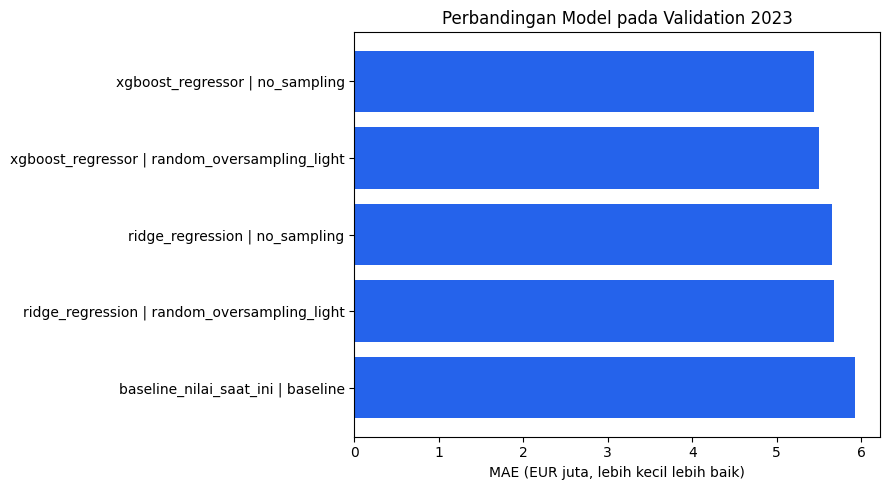

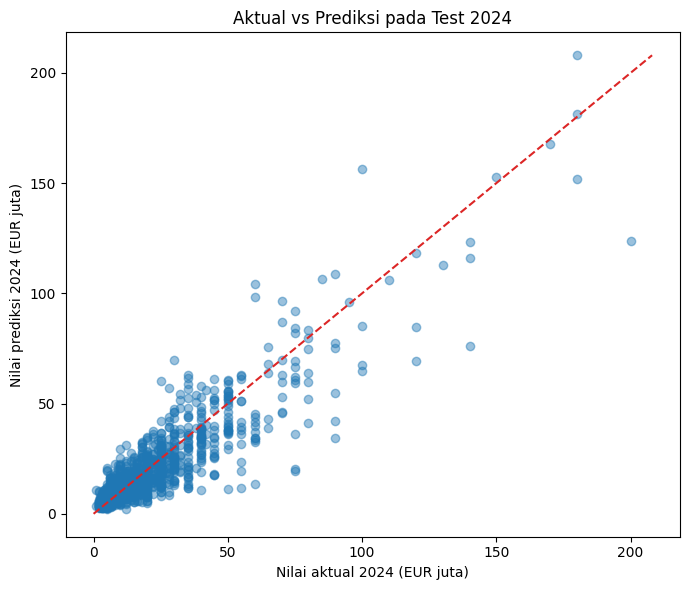

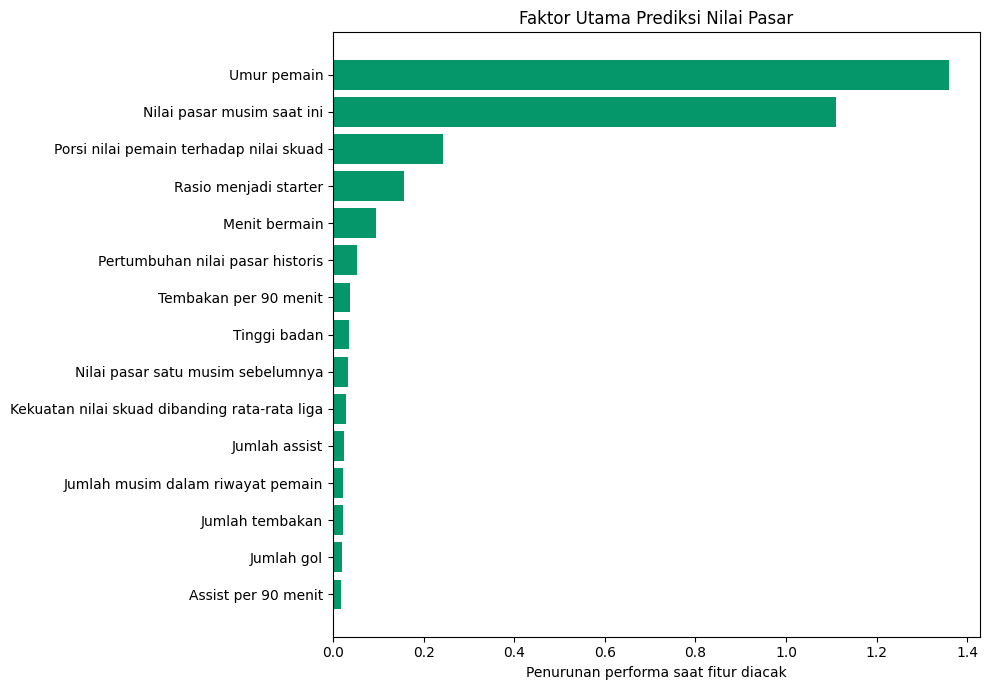

Visualisasi tersimpan di: c:\KULIAH\SEMESTER 6\BIG DATA\UAS\Tugas_UAS_Big-Data\reports\figures


In [10]:
validation_plot = validation_metrics.sort_values("mae").copy()
validation_plot["candidate"] = validation_plot["model"] + " | " + validation_plot["scenario"].fillna("baseline")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(validation_plot["candidate"], validation_plot["mae"], color="#2563eb")
ax.invert_yaxis()
ax.set_xlabel("MAE (EUR juta, lebih kecil lebih baik)")
ax.set_title("Perbandingan Model pada Validation 2023")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "validation_mae.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    test_predictions[TARGET],
    test_predictions["predicted_market_value_mio"],
    alpha=0.45,
)
maximum = max(
    test_predictions[TARGET].max(),
    test_predictions["predicted_market_value_mio"].max(),
)
ax.plot([0, maximum], [0, maximum], linestyle="--", color="#dc2626")
ax.set_xlabel("Nilai aktual 2024 (EUR juta)")
ax.set_ylabel("Nilai prediksi 2024 (EUR juta)")
ax.set_title("Aktual vs Prediksi pada Test 2024")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "test_actual_vs_predicted.png", dpi=180)
plt.show()

top_importance = feature_importance.head(15).sort_values("importance")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top_importance["feature_label"],
    top_importance["importance"],
    color="#059669",
)
ax.set_xlabel("Penurunan performa saat fitur diacak")
ax.set_title("Faktor Utama Prediksi Nilai Pasar")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "feature_importance_user_friendly.png",
    dpi=180,
)
plt.show()

print("Visualisasi tersimpan di:", FIGURE_DIR)